# Homework 2: Functions, Merging & Visualization

This assignment synthesizes concepts from the Week 4 practice notebooks. Use the table below as a reference for where each function was introduced.

### **Concept Reference Map**

| Category | Concept / Function | Original Reference Notebook |
| :--- | :--- | :--- |
| **Data Exploration** | `info()`, `columns`, `unique()`, `head()` | `1-visualization_basics.ipynb` |
| **Statistics** | `describe()`, `mean()`, `pct_change()` | `1-visualization_basics.ipynb` |
| **Manipulation** | `rename()`, `query()`, `drop()`, `set_index()` | `1-visualization_basics.ipynb` / `2-merging_practice.ipynb` |
| **Aggregation** | `groupby()` | `1-visualization_basics.ipynb` |
| **Time Series** | `pd.to_datetime()`, `PeriodIndex` | `2-merging_practice.ipynb` |
| **Merging** | `pd.merge()`, `pd.concat()` | `2-merging_practice.ipynb` |
| **Visualization** | `plot()`, `scatter()`, `barh()` | `1-visualization_basics.ipynb` |

---

## A. Importing Data

Run the cell below to load the WorldBank API function and download population and GDP data for G7 countries.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt


def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = (
        f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}'
        f'?date={start_year}:{end_year}&format=json&per_page=1000'
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    payload = response.json()
    data = payload[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

## A.1 Show info

In [2]:
# CREATE Country list of G7 countries using ISO3 Codes
g7 = ['CAN', 'DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'USA']

In [3]:
gdp_growth_df = get_wb_data('NY.GDP.MKTP.KD.ZG', g7, 2000, 2022)

gdp_growth_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  161 non-null    str    
 1   date             161 non-null    str    
 2   value            161 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.9 KB


## A.2 Show column names


In [4]:
gdp_growth_df.columns

Index(['countryiso3code', 'date', 'value'], dtype='str')

## A.3 Show unique countries

In [5]:
gdp_growth_df['countryiso3code'].unique()

<StringArray>
['CAN', 'DEU', 'FRA', 'GBR', 'ITA', 'JPN', 'USA']
Length: 7, dtype: str

# 1. Show GDP Growth for Japan using above data

## 1.A Rename column for country and value

In [6]:
# Rename country and value columns
gdp_growth_df = gdp_growth_df.rename(columns={
    'countryiso3code': 'country',
    'value': 'gdp_growth'
})
gdp_growth_df.head(2)

,country,date,gdp_growth
0,CAN,2022,4.189036
1,CAN,2021,5.950528


## 1.1 Create new data with only Japan

In [7]:
# Query Japan
df_jp = gdp_growth_df.query("country == 'JPN'").copy()
df_jp.head(2)

,country,date,gdp_growth
115,JPN,2022,0.941999
116,JPN,2021,2.696574


## 1.2 Set index as date, sort index, and drop country column

In [8]:
# Set index 
df_jp = df_jp.set_index('date')
df_jp.head(2)

,country,gdp_growth
date,,
2022,JPN,0.941999
2021,JPN,2.696574


In [9]:
# Drop country column
df_jp = df_jp.drop(columns='country')
df_jp.head(2)

,gdp_growth
date,
2022,0.941999
2021,2.696574


In [10]:
# Sort index makes it so date is descending
df_jp = df_jp.sort_index()
df_jp.head(2)

,gdp_growth
date,
2000,2.764648
2001,0.386103


## 1.3 Plot

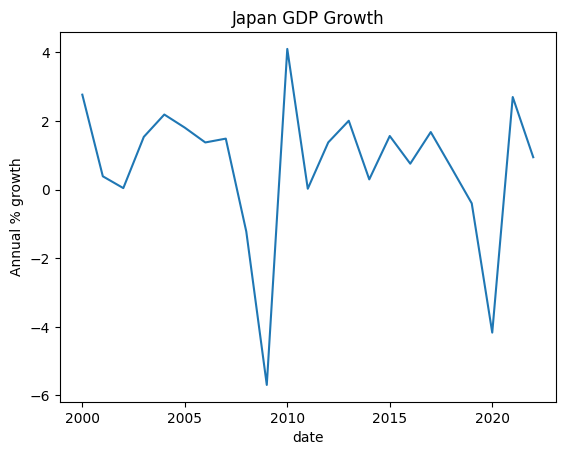

In [11]:
df_jp.plot(y='gdp_growth', legend=False)
plt.title("Japan GDP Growth")
plt.ylabel("Annual % growth");

# 2. Merging Data
## 2.A Importing data

In [12]:
from pathlib import Path

DATA_DIR = Path("../../../data/hw/hw_2")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/hw/hw_2")

df_gdp = pd.read_csv(DATA_DIR / "eichengreen_1.csv")
df_gdp.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN


In [13]:
df_govt_bond = pd.read_csv(DATA_DIR / "eichengreen_2.csv")
df_govt_bond.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,11.062,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,14.424,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 2.1 Filter one country

In [14]:
df_govt_bond.economy.unique()

<StringArray>
['BR', 'CN', 'HK', 'ID', 'JP', 'KH', 'KR', 'LA', 'MM', 'MY', 'PH', 'SG', 'TH',
 'VN']
Length: 14, dtype: str

In [15]:
#MAKE SURE YOU query df_govt_bond
df_govt_bond_vn = df_govt_bond.query("economy == 'VN'").copy()
df_govt_bond_vn.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
299,VN,1997,Vietnam,NaN,1.000000,0.714286,84.50824,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN
300,VN,1998,Vietnam,NaN,0.888889,1.000000,84.61529,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN


In [16]:
#MAKE SURE YOU GET GDP Data df_gdp
df_gdp_vn = df_gdp.query("economy == 'VN'").copy()
df_gdp_vn.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
299,VN,1997,Vietnam,1709.896773,131889.833685,5.904167,19.848841,2.0,2.416667,6.583333,5.0,0.013462,NaN
300,VN,1998,Vietnam,1805.815779,141062.581723,5.170000,20.123863,2.0,2.000000,5.166667,5.0,0.024974,NaN


## 2.2 Filter gdp_pc_pp and set date as index

In [17]:
df_gdp_vn = df_gdp_vn[['date', 'gdp_pc_ppp']].set_index('date')
df_gdp_vn.head(2)

,gdp_pc_ppp
date,
1997,1709.896773
1998,1805.815779


In [18]:
df_govt_bond_vn = df_govt_bond_vn[['date', 'net_borrow']].set_index('date')
df_govt_bond_vn.head(2)

,net_borrow
date,
1997,NaN
1998,NaN


## 2.3 Merge data

In [19]:
# NOTE I sorted index and drop na

df_merge = pd.merge(
    df_gdp_vn,
    df_govt_bond_vn,
    left_index=True,
    right_index=True
).sort_index().dropna()
df_merge.head(2)

,gdp_pc_ppp,net_borrow
date,,
1999,1896.989470,0.126
2000,2048.363759,1.582


## 2.4 Convert to datetime

In [20]:
# No code changes needed
df_merge.index = pd.to_datetime(df_merge.index, format = "%Y")
df_merge.head(2)

,gdp_pc_ppp,net_borrow
date,,
1999-01-01,1896.989470,0.126
2000-01-01,2048.363759,1.582


## 2.4 Plot net_borrow

Text(0, 0.5, '% GDP')

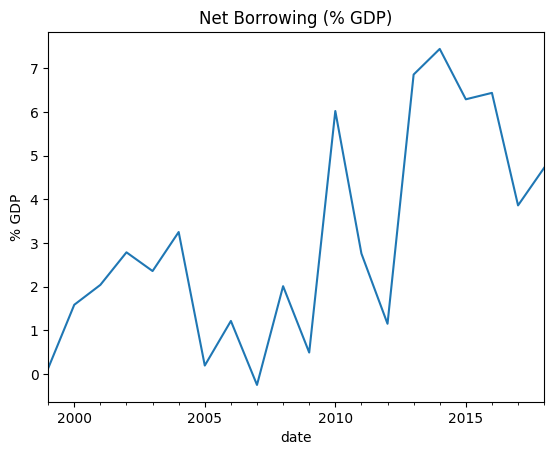

In [21]:
df_merge['net_borrow'].plot()

plt.title("Net Borrowing (% GDP)")
plt.ylabel("% GDP")

# 3. Functions

## 3.A Import Data

In [22]:
DATA_DIR = Path("../../../data/hw/hw_2")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/hw/hw_2")

df_gdp = pd.read_csv(DATA_DIR / "eichengreen_1.csv")
df_govt_bond = pd.read_csv(DATA_DIR / "eichengreen_2.csv")
df_merge_all = pd.concat([df_gdp, df_govt_bond], axis = 'columns')
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'economy', 'date',
       'country', 'net_borrow', 'kai', 'kao', 'bank_con', 'legor_uk',
       'dist_eq', 'bond_market_cap', 'bo_plbn_scaled', 'bo_siln_scaled',
       'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='str')

In [23]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'net_borrow', 'kai',
       'kao', 'bank_con', 'legor_uk', 'dist_eq', 'bond_market_cap',
       'bo_plbn_scaled', 'bo_siln_scaled', 'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='str')

## 3.1 Create function to convert to datetime

In [24]:
def convert_date(df):
    df_copy = df.copy()
    df_copy['date'] = pd.to_datetime(df_copy['date'], format='%Y')
    return df_copy


In [25]:
df_merge_all.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


In [26]:
df_merge_all_converted = convert_date(df_merge_all)
df_merge_all_converted.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 3.2 Rename column function

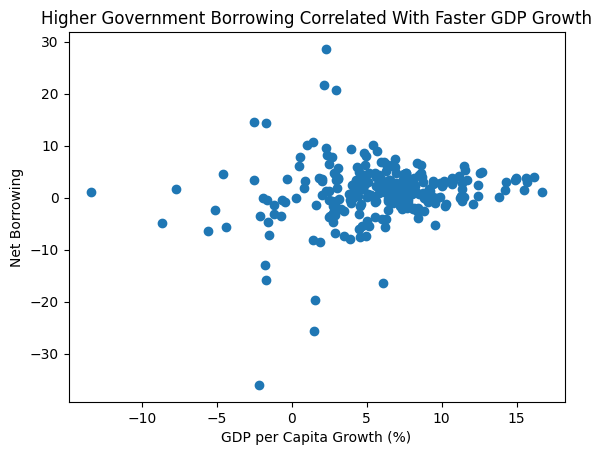

In [27]:
def rename_columns(df):
    df_copy = df.copy()
    df_copy = df_copy.rename(columns={
        'gdp_pc_ppp': 'gdp_per_capita_ppp',
        'net_borrow': 'net_borrowing'
    })
    return df_copy


def plot_scatter(df, x_title, y_title, main_title):
    df_plot = df.sort_values(['economy', 'date']).copy()
    df_plot['gdp_per_capita_growth'] = (
        df_plot.groupby('economy')['gdp_per_capita_ppp'].pct_change(1) * 100
    )

    plt.scatter(df_plot['gdp_per_capita_growth'], df_plot['net_borrowing'])
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(main_title)


df_merge_all_renamed = rename_columns(df_merge_all_converted)

# Note correlation does not equal causation :)
plot_scatter(
    df_merge_all_renamed,
    'GDP per Capita Growth (%)',
    'Net Borrowing',
    'Higher Government Borrowing Correlated With Faster GDP Growth'
)